## DLA CODE OF CONDUCT V2.0

This Code of Conduct defines the principles governing ethical, transparent, and responsible use of Large Language Models (LLMs), online resources, and peer collaboration in the Deep Learning Applications laboratories. This version of the Code of Conduct was refined via a brainstorming session with **ChatGPT Version 5.2** and subsequently adapted to reflect the specific requirements and values of the DLA laboratories. In that spirit, this Code itself models the transparency it expects from you.

***Our goal is not to restrict innovation, but to ensure integrity, accountability, and genuine learning.***

### 1. Transparency in the Use of LLMs and AI Tools

The use of LLMs and AI-assisted tools is permitted — *but it must be transparent*.

* **Explicit Disclosure:** Clearly state if and how LLMs (e.g., ChatGPT, Copilot, Claude, etc.) were used. This includes code generation, debugging, data analysis, experiment design, report writing, or conceptual clarification.
* **Description of Contribution:** Briefly describe what the tool contributed and how you modified, verified, or extended its output.
* **Acknowledgment of Limitations:** Recognize that LLM outputs may contain errors, biases, or non-optimal solutions. You are responsible for verifying correctness, appropriateness, and academic integrity.

***Using AI does not reduce your responsibility for the final result.***

### 2. Proper Attribution and Documentation

Deep learning builds on existing work — responsibly.

* **Attribution:** Properly cite all external resources, including: Code snippets, Tutorials, Documentation, Datasets, Pretrained models, Research papers, and AI-generated content.
* **Reproducibility:** Clearly document tools, libraries, model versions, hyperparameters, and experimental setups so that your work can be reproduced.
* **Clarity of Modifications:** If you adapt external code, explicitly indicate what you changed and why.

***Transparency is a sign of scientific maturity — not weakness.***

### 3. Collaboration and Individual Responsibility

Discussion is encouraged. Copying is not.

* **Collaborative Learning:** You are encouraged to discuss concepts, debugging strategies, and approaches with classmates.
* **Individual Submission:** Your submitted solution must reflect your own understanding and implementation.
* **No Direct Sharing of Solutions:** Do not share complete solutions, trained models, or reports. Do not submit another person's work — or AI-generated work — as your own without meaningful engagement and proper disclosure.

***If you cannot explain your submission, it is not your submission.***

### 4. Accountability and Academic Integrity

You are responsible for everything you submit. Failure to comply with these guidelines may result in review by the course examination commission and can lead to disciplinary measures in accordance with university regulations.

***Integrity is part of your training as a machine learning practitioner.***

### 5. The Spirit of This Code of Conduct

This course prepares you to work in a field where:

* Reproducibility matters
* Ethical considerations matter
* Transparency matters
* Responsible AI use matters

***The purpose of this Code of Conduct is not surveillance — it is professional formation.***

### TL;DR

Use AI; Don’t let AI use you; Be transparent; Cite everything; Do your own thinking.

***If you can’t explain it, you probably shouldn’t submit it.***

---
---

## Introduction

In this first laboratory we will see a few ways to exploit and adapt pre-trained models to solve new problems. We will start first by downloading and instantiating a new dataset and establishing a stable and reproducible baseline model based on a pre-trained CNN.

---

## Exercise 1 (Warmup): Exploratory Data Analysis and a Stable Baseline

For this laboratory we will work with [The German Traffic Sign Detection Benchmark](https://benchmark.ini.rub.de/) [1]. We will begin, not with *detection*, but with a simpler traffic sign *classification* problem. This has two advantages: (1) the images are *smaller* than in the detection benchmark; and (2) a wrapper for the GTSRB dataset is conveniently included in the `torchvision` library.  

[1] Houben S, Stallkamp J, Salmen J, Schlipsing M, Igel C. Detection of traffic signs in real-world images: The German Traffic Sign Detection Benchmark. In The 2013 International Joint Conference on Neural Networks (IJCNN), 2013.

### Exercise 1.1: Exploratory Data Analysis

A good best practice to adopt in all experimental deep learning projects is thorough *exploratory data analysis*. In this exercise you should instantiate the GTSRB Dataset, inspect some images, and do some statistical analysis of the distribution of data (and metadata). A goal here is to keep an eye out for anything that might be problematic in what is to come.



Configurazione dell'Ambiente e Importazione Dati

In [1]:
# Standard imports and aliases.
import numpy as np                          # Libreria per operazioni numeriche (array, algebra, ecc.)
import matplotlib.pyplot as plt             # Libreria per la visualizzazione di grafici e immagini
import torch                                # Libreria principale per il deep learning
import torchvision.transforms.v2 as T       # Libreria per la trasformazione di immagini
from torchvision.datasets import GTSRB      # Dataset di immagini di segnali stradali

device = 'cuda' if torch.cuda.is_available() else 'cpu' # guardo se esiste una scheda Nvidia altrimenti usa CPU

# Carichiamo il dataset di training SENZA trasformazioni
# transform=None → immagini "grezze"
ds_train_raw = GTSRB('data/' , split = 'train' , transform = None, download = True)
ds_test_raw = GTSRB('data/' , split = 'test' , transform = None, download = True)

In [2]:
# ISPEZIONE DI UNA IMMAGINE
# .size → dimensioni immagine (larghezza, altezza)

ds_train_raw[0][0].size

(29, 30)

In [3]:
ds_train_raw[1][0].size

(30, 30)

Ispezione Visiva del Dataset

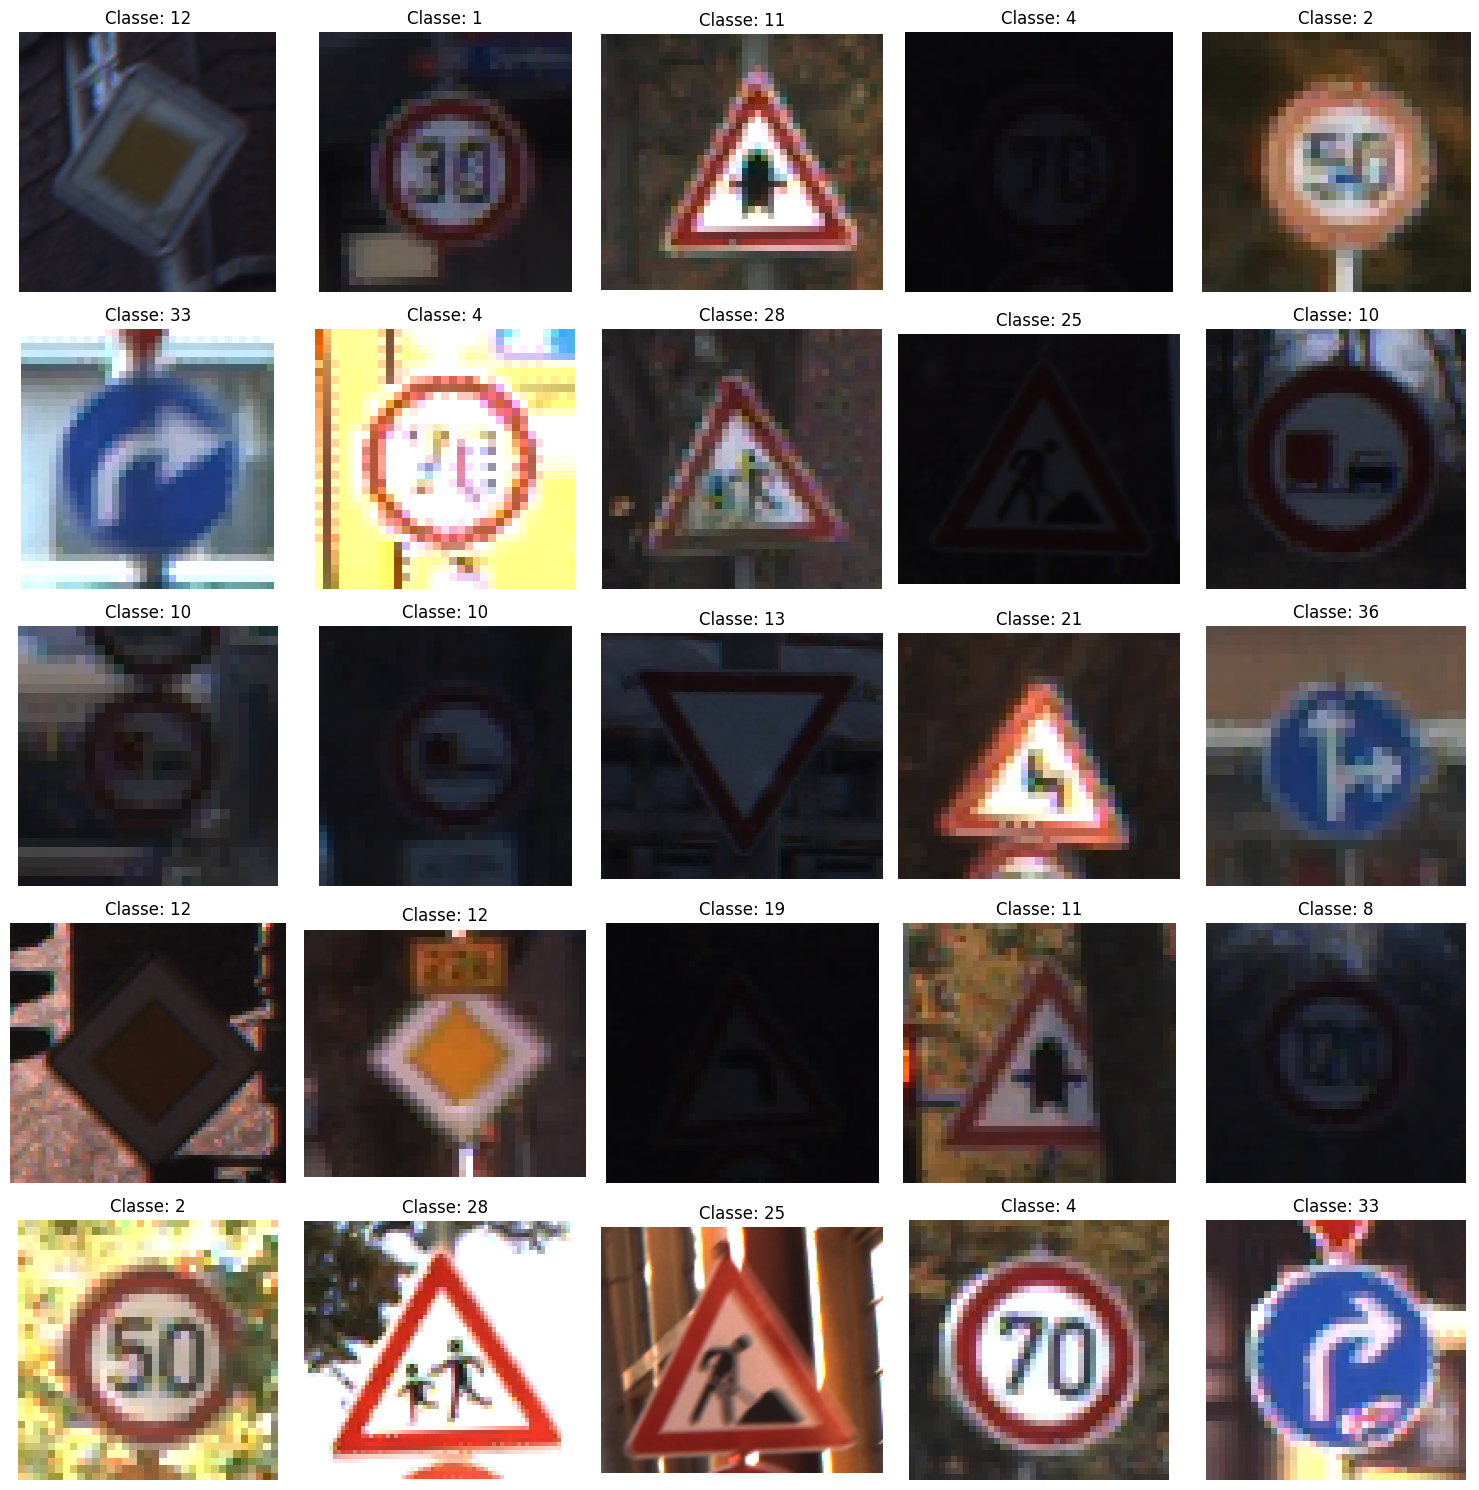

In [4]:
# 1. CARICAMENTO DATI GREZZI (Solo per ispezione visiva)
# Carichiamo il dataset SENZA passare il parametro 'transform'. 
# PyTorch ci restituirà le immagini originali nel formato PIL (Python Imaging Library).
ds_vis = GTSRB('data/', split='train', download=True)

# 2. CAMPIONAMENTO CASUALE (Griglia più piccola per immagini più grandi)
num_samples = 25 # 25 immagini in una griglia 5x5
random_indices = np.random.choice(len(ds_vis), num_samples, replace=False) # selezioniamo 25 indici casuali senza ripetizione

# Creiamo una figura grande per dare spazio alle immagini
plt.figure(figsize=(15, 15))

for idx, sample_idx in enumerate(random_indices): # scorriamo gli indici casuali
    im, cls = ds_vis[sample_idx] # Estraiamo l'immagine grezza e la classe (label)
    
    plt.subplot(5, 5, idx + 1) # creiamo una griglia 5x5 e inseriamo l'immagine
    
    # Essendo un'immagine grezza, non serve né denormalizzare né usare "permute"!
    plt.imshow(im)  
    
    # Impostiamo un font proporzionato per il titolo
    plt.title(f'Classe: {cls}', fontsize=12)
    plt.axis('off')

# Organizza gli spazi in modo pulito
plt.tight_layout() 
plt.show()

In [5]:
# voglio capire come funziona il dataset, in particolare se il dataset è bilanciato, in un pandas dataframe #
import pandas as pd
import os

# Definiamo il nome del file di cache dove salviamo le statistiche del dataset
cache_path = 'df_stats_cache.csv'

if os.path.exists(cache_path):
    # SE IL FILE ESISTE: lo carichiamo (impiega meno di 1 secondo)
    print("Caricamento statistiche dalla cache...")
    df_stats = pd.read_csv(cache_path)
else:
    # SE IL FILE NON ESISTE: eseguiamo il calcolo lento
    print("Calcolo statistiche in corso (operazione lunga, solo la prima volta)...")
    
    # Usa il dataset RAW senza transform
    df_stats = pd.DataFrame([(cls, im.size[1], im.size[0])  # classe, altezza, larghezza
                            for (im, cls) in ds_train_raw], columns=['CLS', 'HEIGHT', 'WIDTH'])
    df_stats['AR'] = df_stats['WIDTH'] / df_stats['HEIGHT']
    # Aspect Ratio (AR), ovvero il rapporto tra larghezza e altezza. Questo ci dice se le immagini sono quadrate, schiacciate o allungate.
    
    # Salviamo per le prossime volte
    df_stats.to_csv(cache_path, index=False)
    print(f"Calcolo completato e salvato in {cache_path}")

# Mostriamo le prime righe per conferma
df_stats.head()

Caricamento statistiche dalla cache...


,CLS,HEIGHT,WIDTH,AR
0,0,30,29,0.966667
1,0,30,30,1.000000
2,0,30,30,1.000000
3,0,31,31,1.000000
4,0,32,30,0.937500


In [6]:
df_stats.describe()
# varianza è alta #
# Classi Sbilanciate (CLS): La media è 15.89, ma le classi arrivano fino a 43 (zero + 42 = 43 classi totali). L'istogramma ti ha confermato visivamente che ci sono enormi picchi per alcune classi e valli profonde per altre. Il modello farà fatica con i cartelli rari.
# max: c'è un'immagine gigante da 225x243 pixel! La deviazione standard (std) alta conferma questa grande varianza.
# L'Aspect Ratio medio è 1.01 e la mediana è 1.00. Questo è un dato rassicurante: significa che quasi tutti i cartelli sono quadrati

,CLS,HEIGHT,WIDTH,AR
count,26640.000000,26640.000000,26640.000000,26640.000000
mean,15.887387,50.365128,50.933784,1.008718
std,12.044099,23.161523,24.373418,0.072100
min,0.000000,25.000000,25.000000,0.368132
25%,5.000000,35.000000,35.000000,0.972222
50%,12.000000,43.000000,43.000000,1.000000
75%,25.000000,58.000000,58.000000,1.044444
max,42.000000,225.000000,243.000000,1.417808


array([[<Axes: title={'center': 'CLS'}>,
        <Axes: title={'center': 'HEIGHT'}>],
       [<Axes: title={'center': 'WIDTH'}>,
        <Axes: title={'center': 'AR'}>]], dtype=object)

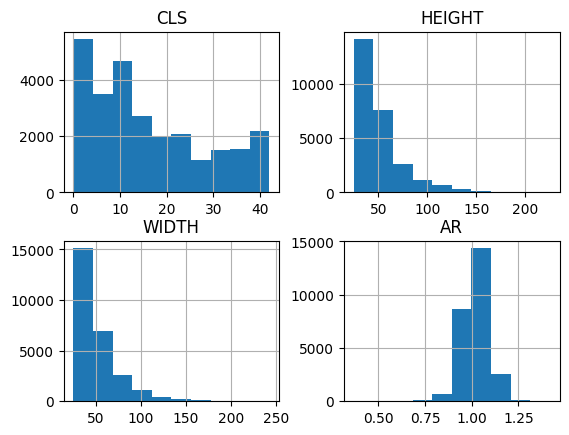

In [7]:
df_stats.hist()
# si vede che altezza e larghezza sono lunghe meno di 100 #
# classi non troppe bilanciate #

In [8]:
# finalizzare la nostra impletentazione del dataset, visto che la risoluzione non è costante dobbiamo prendere una decisione #
# normalizzo e uso la statistiche fissate di normalizzazione #
# We use the standard normalization statistics from the torchvision impletation of ResNet#
import torchvision.transforms.v2 as T
from torchvision.datasets import GTSRB

transform = T.Compose([
    T.Resize(70),            # il lato più corto viene portato a 70 pixel
    T.CenterCrop((64, 64)),  # sempre lo stesso crop
    T.ToImage(),             # Converte da PIL a tensore PyTorch (C, H, W)
    T.ToDtype(torch.float32, scale=True), # Converte in float e scala i valori nell'intervallo [0, 1]
    T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)) # normalizza usando le statistiche di ImageNet
])
# prima con resize faccio in modo che un lato sia di 70, dopo con random crop prendo un pezzo di 64x64, poi lo normalizzo #

ds_train = GTSRB('data/', split = 'train', transform = transform, download = True)
ds_test = GTSRB('data/', split = 'test', transform = transform, download = True)

print(f"✓ Dataset caricato: {len(ds_train)} train, {len(ds_test)} test")

✓ Dataset caricato: 26640 train, 12630 test


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.1589177..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8610327..-0.23581691].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5805321..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8096584..1.8556867].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0322802..-0.13124162].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7582842..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7411594..2.094785

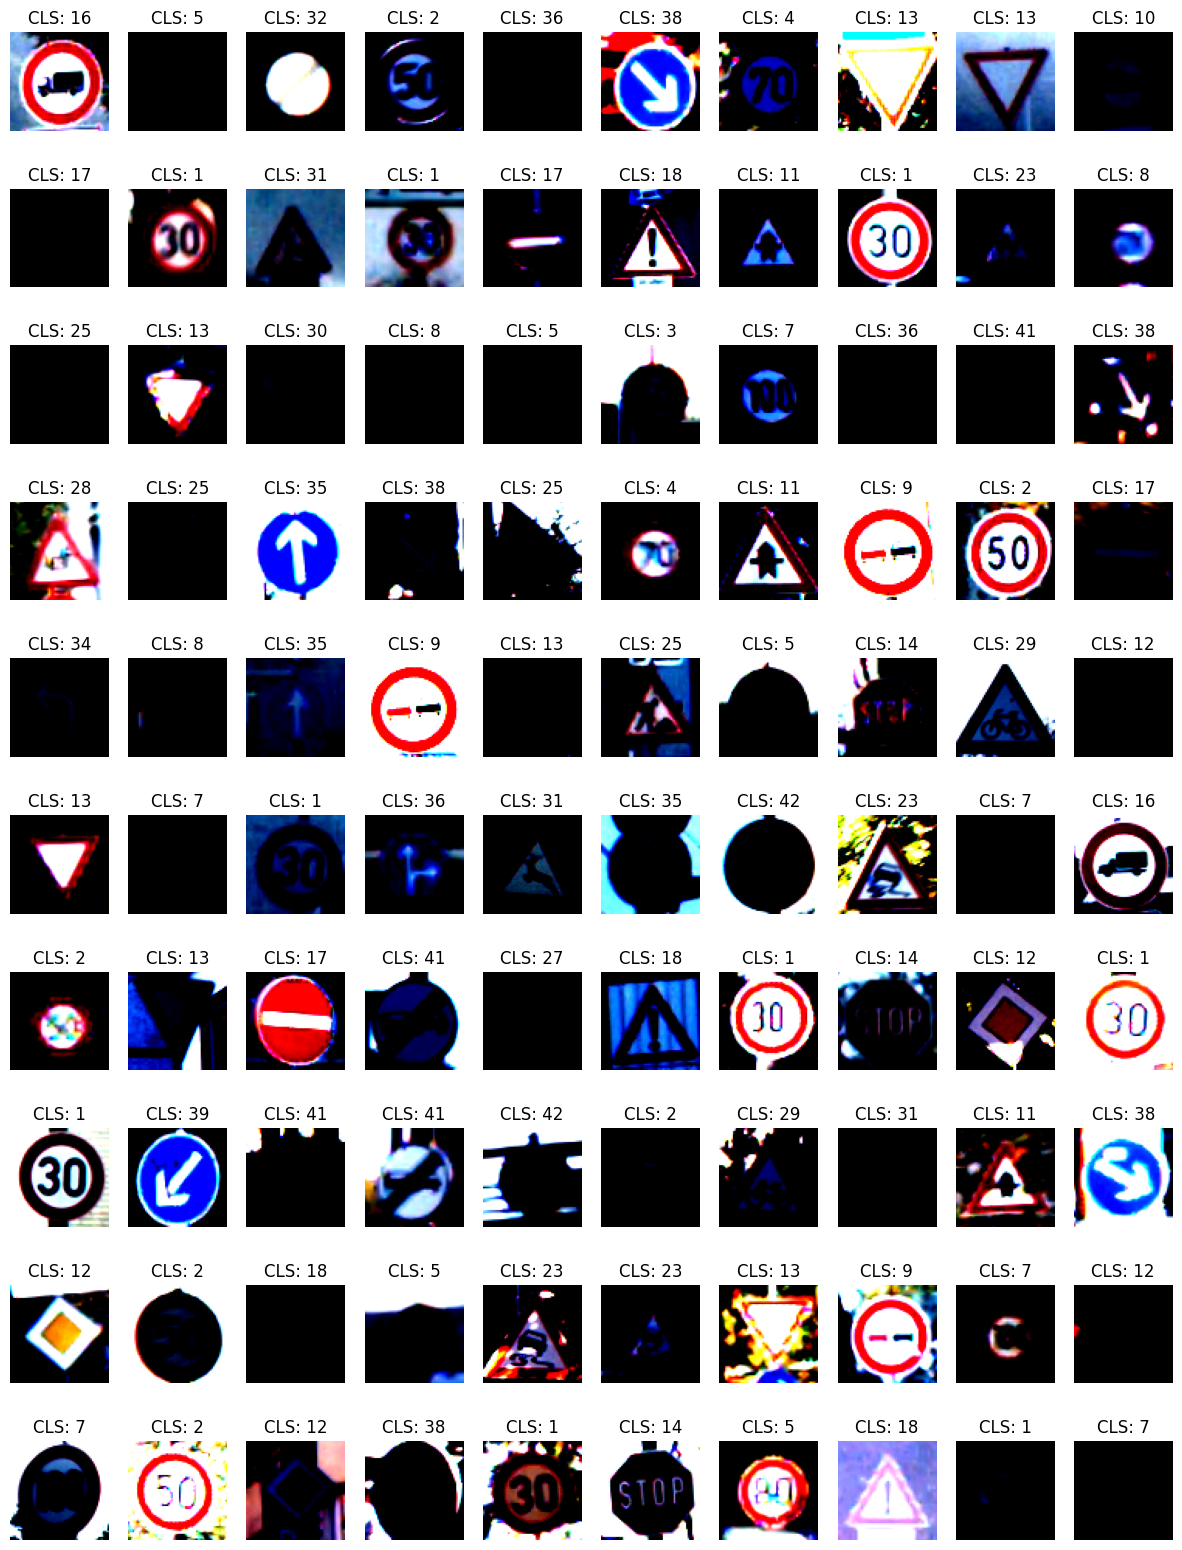

In [9]:
# visualizzazione dati a cas tra 100 come samples immagini  ADESSO A GRANDEZZA UGUALE #
num_samples = 100
# Selezioniamo 100 indici casuali e prendiamo (immagine, classe)
image_samples = [ds_train[idx] for idx in np.random.choice(range(len(ds_train)), num_samples)]

#faccio dei subplot sul campione#
plt.figure(figsize = (15,20) )
for (idx, (im, cls)) in enumerate(image_samples):
    plt.subplot(10,10, idx + 1)
    plt.imshow(im.permute([1, 2, 0])) # permuto per avere (H, W, C) per la visualizzazione
    plt.title(f'CLS: {cls}')
    plt.axis('off')

In [ ]:
# Configurazione dell'ambiente (Environment Setup):
#Abbiamo creato un ambiente isolato con Anaconda (DLA2026) per evitare conflitti tra librerie.
#Abbiamo installato le dipendenze fondamentali: PyTorch (framework principale per il deep learning), torchvision (per dataset e modelli di visione), e matplotlib/pandas (per visualizzazione e analisi dei dati).

# Acquisizione del Dataset (Data Loading):
#Abbiamo scaricato il dataset GTSRB (German Traffic Sign Recognition Benchmark) tramite torchvision.
#Abbiamo suddiviso i dati in ds_train (per l’addestramento) e ds_test (per la valutazione finale del modello).

# Analisi Esplorativa dei Dati - EDA (Exploratory Data Analysis):
#Ispezione visiva: Abbiamo visualizzato campioni casuali di immagini per comprendere la natura del dataset (contenuto, qualità, variabilità).
#Analisi dimensionale: Abbiamo osservato che le immagini hanno risoluzioni variabili (es. 30x29, 45x42), incompatibili con l’input fisso richiesto dalle reti neurali.
#Analisi statistica con Pandas: Utilizzando un sistema di caching per ottimizzare i tempi di esecuzione, abbiamo costruito un DataFrame contenente metadati (classe, dimensioni, aspect ratio), analizzando medie, deviazioni standard e distribuzioni.
#Aspect Ratio: Abbiamo verificato che le immagini sono prevalentemente quadrate (AR ≈ 1), semplificando il processo di resizing.
#Distribuzione delle classi: Abbiamo identificato uno sbilanciamento tra le classi (data imbalance), con alcune molto più rappresentate di altre, potenziale fonte di bias per il modello.

# Definizione della Pipeline di Pre-processing:
#Abbiamo definito una pipeline di trasformazioni per standardizzare l’input del modello:
#Resize: Ridimensionamento dell’immagine mantenendo le proporzioni, per garantire una dimensione minima adeguata.
#CenterCrop: Ritaglio centrale fisso a 64x64 pixel per ottenere input di dimensione uniforme (scelta deterministica per una baseline stabile).
#ToImage + ToDtype: Conversione dell’immagine in tensore PyTorch in formato float32 e scalato nell’intervallo [0,1].
#Normalize: Normalizzazione utilizzando media e deviazione standard di ImageNet, necessaria per l’utilizzo di modelli pre-addestrati come ResNet.

### Analysis

Deep Learning is very much an *experimental* discipline. Experiments are *nothing* without analysis and interpretation. Be sure to **always** stop and analyze the results of preliminary explorations. Note anything significant and -- importantly -- anything that is going to be relevant for what comes next.

So... In this Markdown cell you should collect and report (using, for the love of God, the *rich markup capabilities of Markdown*) any relevant findings you have made before proceding.

**Important Warning**: This is the **one and only** time I will remind you of the need to provide *analysis* and interpretation of your experimental methodology and results. The responsibility is *yours* to include it elsewhere.


---
### Exercise 1.2: A Stable and Reproducible Baseline

In this exercise you should implement code to use a pretrained network as a *feature extractor* that, instead of *classifying* images in input, should return the *feature representation* from the last layer of the pretrained model before the classifier. These features, extracted from the train set, should be used to train a *classical* model for classification (e.g. an SVM, a Nearest Neighbor, or a Linear Discriminant classifier from Scikit-learn). Evaluate the performance of this baseline model on the features extracted from the test set.

In [10]:
from torchvision.models import list_models, get_model

list_models()
# modelli pre-addestrati che torchvision ti mette a disposizione

['alexnet',
 'convnext_base',
 'convnext_large',
 'convnext_small',
 'convnext_tiny',
 'deeplabv3_mobilenet_v3_large',
 'deeplabv3_resnet101',
 'deeplabv3_resnet50',
 'densenet121',
 'densenet161',
 'densenet169',
 'densenet201',
 'efficientnet_b0',
 'efficientnet_b1',
 'efficientnet_b2',
 'efficientnet_b3',
 'efficientnet_b4',
 'efficientnet_b5',
 'efficientnet_b6',
 'efficientnet_b7',
 'efficientnet_v2_l',
 'efficientnet_v2_m',
 'efficientnet_v2_s',
 'fasterrcnn_mobilenet_v3_large_320_fpn',
 'fasterrcnn_mobilenet_v3_large_fpn',
 'fasterrcnn_resnet50_fpn',
 'fasterrcnn_resnet50_fpn_v2',
 'fcn_resnet101',
 'fcn_resnet50',
 'fcos_resnet50_fpn',
 'googlenet',
 'inception_v3',
 'keypointrcnn_resnet50_fpn',
 'lraspp_mobilenet_v3_large',
 'maskrcnn_resnet50_fpn',
 'maskrcnn_resnet50_fpn_v2',
 'maxvit_t',
 'mc3_18',
 'mnasnet0_5',
 'mnasnet0_75',
 'mnasnet1_0',
 'mnasnet1_3',
 'mobilenet_v2',
 'mobilenet_v3_large',
 'mobilenet_v3_small',
 'mvit_v1_b',
 'mvit_v2_s',
 'quantized_googlenet',
 '

In [11]:
from torch.utils.data import DataLoader
import torch.nn as nn

batch_size = 1024
dl_train = DataLoader(ds_train, batch_size = batch_size, shuffle = True) 
dl_test = DataLoader(ds_test, batch_size = batch_size, shuffle = False)
#shuffle vuole dire che mescola le immagini in modo casuale, utile durante il training per evitare bias nell’ordine dei dati

# Load our Resnet model #
model = get_model('resnet18', weights = 'DEFAULT')
model.fc = nn.Identity() # sostituito il layer di classificazione con una funzione identità per ottenere direttamente le feature
model = model.to(device) # Spostiamo il modello su GPU o CPU

In [12]:
from tqdm import tqdm
# creo due liste per raccogliere i dati, cambia la modalità di inferenza con eval (modello preaddestrato),
# itero su ogni batch di immagini, ho una lista di tensori con i feature e le classi

train_feats = []                        # lista di tensori con i feature
train_classes = []                      # lista di tensori con le classi
model.eval()                            # cambia la modalità di inferenza con eval (modello preaddestrato)
for (ims, cls) in tqdm(dl_train):       # itero su ogni batch di immagini
    ims = ims.to(device)
    with torch.no_grad():               # disabilita il calcolo del gradiente
        train_feats.append(model(ims))  # otteniamo feature dal modello
    train_classes.append(cls)
train_feats = torch.vstack(train_feats).cpu() 
train_classes = torch.concat(train_classes)

100%|██████████| 27/27 [00:12<00:00,  2.10it/s]


In [13]:
# Vogliamo pescare questo output: (avgpool): AdaptiveAvgPool2d(output_size=(1, 1)), mantenendo tutti i pesi del modello
# 26640 è l'esatto numero di immagini del tuo training set (lo avevamo visto nel Dataframe Pandas).
# 512 è la lunghezza del vettore di features estratto dalla ResNet per ogni singola immagine.
train_feats.shape

torch.Size([26640, 512])

In [14]:
# stessa cosa del train ma sul test set

test_feats = []
test_classes = []
model.eval()
for (ims, cls) in tqdm(dl_test):
    ims = ims.to(device)
    with torch.no_grad():
        test_feats.append(model(ims).cpu())
    test_classes.append(cls)
test_feats = torch.vstack(test_feats).cpu()
test_classes = torch.concat(test_classes)

100%|██████████| 13/13 [00:06<00:00,  1.89it/s]


In [15]:
ds_test

Dataset GTSRB
    Number of datapoints: 12630
    Root location: data/
    StandardTransform
Transform: Compose(
                 Resize(size=[70], interpolation=InterpolationMode.BILINEAR, antialias=True)
                 CenterCrop(size=(64, 64))
                 ToImage()
                 ToDtype(scale=True)
                 Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
           )

In [16]:
test_feats.shape

torch.Size([12630, 512])

In [17]:
# reproducibile baseline, usando un support vector machine SVC, c coeffeciente di controllo, rbf non uso kernel

from sklearn.svm import SVC

svc = SVC(kernel='linear')
svc.fit(train_feats, train_classes) 
# SVM cercherà di tracciare dei "confini" matematici per separare i 43 tipi di cartelli
# degree 3, gamma scale, coef0 = 0.0): Visto che hai scelto in modo molto intelligente il kernel='linear', 
# l'SVM ignora in automatico questi tre parametri (che servono invece per i kernel curvi, come quelli polinomiali o RBF).

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [18]:
from sklearn.metrics import classification_report

print(classification_report(test_classes, svc.predict(test_feats))) #gemini mi dice di invertire test con svc.predict(test_feats)

# accuratezza alta, i numeri sono le categorie
# la sfida è migliorare questi risultati

              precision    recall  f1-score   support

           0       0.21      0.17      0.19        60
           1       0.52      0.69      0.59       720
           2       0.48      0.49      0.48       750
           3       0.34      0.36      0.35       450
           4       0.60      0.58      0.59       660
           5       0.54      0.52      0.53       630
           6       0.98      0.83      0.90       150
           7       0.58      0.53      0.55       450
           8       0.46      0.37      0.41       450
           9       0.91      0.78      0.84       480
          10       0.84      0.89      0.86       660
          11       0.48      0.59      0.53       420
          12       0.95      0.98      0.96       690
          13       0.95      0.99      0.97       720
          14       0.91      0.84      0.87       270
          15       0.99      0.97      0.98       210
          16       0.89      0.83      0.86       150
          17       0.97    

In [ ]:
# 1. Backbone Repurposing
# Invece di addestrare una rete da zero, abbiamo preso una ResNet-18 pre-addestrata su ImageNet. 
# Abbiamo rimosso lo strato di classificazione finale e l'abbiamo utilizzata come feature extractor. 
# Questo significa che sfruttiamo una rete che già sa riconoscere bordi, forme e texture generali, utili anche per i cartelli stradali.

# 2. Estrazione delle Feature
# L'intero dataset (Train e Test) è stato passato attraverso la rete "mozzata":
# - Input: immagini preprocessate 64x64 normalizzate.
# - Output: vettori di 512 dimensioni per ciascuna immagine.
# Abbiamo così ottenuto due matrici, train_feats e test_feats, che rappresentano in modo numerico le informazioni visive dei cartelli.

# 3. Addestramento del Modello Classico (SVM)
# Abbiamo usato un classificatore classico, la Support Vector Machine (SVM) con kernel lineare, per distinguere le 43 classi usando come input i vettori di feature.
# La scelta del kernel lineare è motivata dal fatto che le feature estratte da una rete profonda sono solitamente già ben separabili linearmente, rendendo il training computazionalmente efficiente e stabile.

# 4. Analisi dei Risultati
# Il classification_report ha fornito le metriche di riferimento:
# - Accuracy di baseline sul test set: ~63%.
# - F1-score variabile: per le classi maggiormente rappresentate (es. classe 12 o 13) il modello ottiene valori molto alti (~0.96), mentre per le classi rare (es. classe 37 con solo 36 immagini) i valori sono molto bassi (~0.12).
# - La colonna support conferma che la principale causa di errore è lo sbilanciamento del dataset, come previsto nell'EDA della Sezione 1.1.

# Questa baseline è stabile e riproducibile, e costituisce un punto di partenza solido prima di eventuali miglioramenti tramite fine-tuning o tecniche di bilanciamento dei dati.


---
### Exercise 1.3: A Fine-tuning Baseline

In this exercise you should try to *improve* on the stable baseline given by the feature extraction + SVM (or whatever) classifier you produced in the previous lecture. To do this, you should *fine-tune* the ResNet-18 (or whatever model you chose) to solve the new classification task.

To do this, you could proceed by:
1. Loading the ResNet-18 (or whatever) model and replacing the final FC layer (the classifier) with a *new* classifier. This could be a single Linear layer, or could be an MLP.
2. Training the resulting model on the GTSRB dataset for a few epochs.
3. Evaluating the resulting performance.

Some things you should probably consider (especially thinking about the *next* exercise):
+ You should be monitoring not only the loss on the training set, but also a *validation* loss on an *independent* validation set. Split the training set into two datasets: one with, say, 80% of the original training samples, and another with the remaining 20%. You can use this smaller set to monitor performance and check for *overfitting*.
+ Maybe the best strategy is to not fine-tune *all* layers, but only the last few. Think about *selectively* fine-tuning layers of the network.
+ Maybe a *single* linear layer isn't the best option for the classifier. Think about using an MLP instead.

In [19]:
# Funzioni di training e valutazione rimosse.
# Ora utilizziamo le funzioni centralizzate definite in engine.py
# per garantire coerenza e performance migliori in tutti gli esperimenti.

In [20]:
model = get_model('resnet18', weights='DEFAULT')

# Sostituisci il layer finale con uno nuovo (Linear) per 43 classi
model.fc = nn.Linear(512, 43)

# Congela solo il backbone (non fc)
for name, param in model.named_parameters():
    if not name.startswith('fc'):  # ← Escludi il nuovo layer (il quale verra addestrato)
        param.requires_grad = False

model = model.to(device)

# The training dataloader
batch_size = 1024
dl_train = DataLoader(ds_train, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True) # pin_memory per il traferimento in GPU
dl_test = DataLoader(ds_test, batch_size=batch_size, shuffle=False, num_workers=1) # shuffle=False per il test set per valutazione stabile

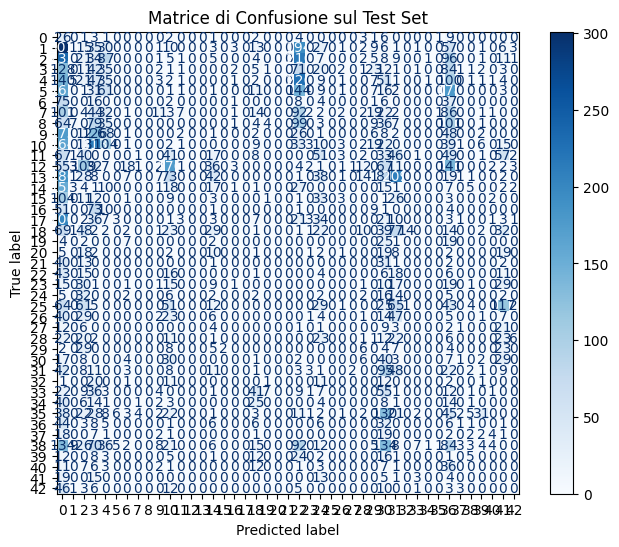

In [21]:
# aggiunto per ottenere la matrice di confusione
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrix(model, dataloader, device):
    model.eval() # Mette il modello in modalità valutazione
    all_preds = []
    all_labels = []
    
    with torch.no_grad(): # Disabilita il calcolo dei gradienti
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            
            # Ottieni la classe predetta
            _, preds = torch.max(outputs, 1) 
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    # Calcola la matrice e usa la funzione display di scikit-learn
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    
    # Crea il plot
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(cmap='Blues', ax=ax, values_format='d')
    plt.title('Matrice di Confusione sul Test Set')
    plt.show()

# Esegui la funzione
plot_confusion_matrix(model, dl_test, device=device)

In [22]:
import torch

# Controlla cosa è disponibile e assegna il dispositivo migliore
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Ottimo! Stai usando la GPU NVIDIA:", torch.cuda.get_device_name(0))
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Ottimo! Stai usando l'acceleratore Apple Silicon (Mac M1/M2/M3).")
else:
    device = torch.device("cpu")
    print("ATTENZIONE: Stai usando la CPU. L'addestramento sarà molto lento!")

# Stampa il dispositivo finale assegnato
print(f"Dispositivo impostato su: {device}")

Ottimo! Stai usando la GPU NVIDIA: NVIDIA GeForce RTX 3080
Dispositivo impostato su: cuda


In [ ]:
# 1. Pulizia del codice (Best Practices)
# Abbiamo corretto l'uso improprio di `num_workers=True` trasformandolo in `num_workers=1` per il DataLoader di test, garantendo stabilità e evitando comportamenti inaspettati legati al multiprocessing.

# 2. Creazione di strumenti diagnostici
# Abbiamo implementato una funzione per tracciare la matrice di confusione usando solo matplotlib e scikit-learn. 
# Questo ci permette di visualizzare non solo l’accuratezza globale, ma anche gli errori specifici tra le 43 classi di cartelli.

# 3. Ottimizzazione degli iperparametri (Tuning)
# Abbiamo studiato l’interazione tra numero di epoche e learning rate monitorando la funzione di loss durante l’allenamento. 
# Questo ci ha permesso di diagnosticare fenomeni di underfitting o plateau e migliorare l’apprendimento del nuovo classificatore.

# 4. Diagnosi dello sbilanciamento (Class Imbalance)
# Analizzando il classification report, abbiamo evidenziato che l’attuale limite di accuracy (~53%) non dipende dalla capacità della rete neurale, ma dal forte sbilanciamento del dataset. 
# Le classi con pochi esempi risultano più difficili da classificare, confermando quanto anticipato nell’EDA della Sezione 1.1.

---
---
## Exercise 2: Pipeline Consolidation

Consolidate your implementation. When building applications based asd on Deep Learning, you will inevitably need to run many, many experiments. So, it is *always* a good idea to engineer a reproducible pipeline that allows you to run (and re-run) experiments with different hyperparameters. In this exercise you should do exactly this: engineer a deep learning pipeline that encapsulates (at least) training and evaluation so that you can easily and reproducibly run multiple experiments and compare the results.

Some things to think about when engineering this pipeline:
- **Model and Loss (and maybe Optimizer) Abstraction**: An important variable in training deep models is the model (obviously), the loss (somewhat less obvious), and the optimizer (less obvious) used during training. Your pipeline should probably be able to adapt to these changing configurations.
- **Configuration management**: Instead of global variables specializing each cell, thread a configuration object through your code (or use a singleton). If you are planning to use an IDE and not this notebook for the lab, you might consider using a configuration management library like [OmegaConf](https://omegaconf.readthedocs.io/en/2.3_branch/) which will help instrument your code so that you can pass configuration overrides via command line arguments.
- **Logging**: You will invariably need to run and compare multiple experiments. Instrument your code for monitoring training. Good options are [Tensorboard](https://docs.pytorch.org/tutorials/recipes/recipes/tensorboard_with_pytorch.html) or [Weights and Biases (WandB)](https://wandb.ai/site/). My PhD students seem to overwhelmingly prefer Weights and Biases. The configuration parameters should be used to facilitate distinguishing and comparing multiple runs with multiple hyperparameters.

In [ ]:
# Your code here.

# Or, even better: Consolidate your code in separate Python modules that you can 
# import here and then REUSE.

# adottare un sistema di gestione delle configurazioni, come lr, losses, batchrate, epoche
# su weight e losses vanno provati modelli sul train set e validation set (non fatto nell'esempio finale)

In [ ]:
pip install wandb

In [42]:
import wandb

# Inserisci la tua API key direttamente qui come stringa
wandb.login(key="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")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\franc\_netrc
wandb: Currently logged in as: francesco-faggioli (francesco-faggioli-university-of-florence) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [54]:
import importlib
import engine # Importiamo l'intero modulo

# Questo comando FORZA Jupyter a rileggere il file engine.py salvato su disco!
importlib.reload(engine)

# Ora possiamo ripescare la funzione aggiornata

<module 'engine' from 'c:\\Users\\franc\\Desktop\\DLA_Lab\\DLA_Lab\\engine.py'>

In [24]:
# =========================================================================
# ESEGUIRE PRIMA DEGLI ESPERIMENTI (Split Robusto Anti-Leakage)
# =========================================================================
from torch.utils.data import DataLoader, Subset
import torch
import numpy as np

# 1. Split basato sui 'track' (30 immagini per ogni cartello fisico in GTSRB)
# Questo assicura che un cartello sia o tutto nel Training o tutto nel Validation.
num_samples = len(ds_train_raw)  # ← Usa dataset RAW
num_tracks = num_samples // 30
remaining = num_samples % 30

track_indices = np.arange(num_tracks)
np.random.seed(42)
np.random.shuffle(track_indices)

train_track_count = int(0.8 * num_tracks)
idx_train_tracks = track_indices[:train_track_count]
idx_val_tracks = track_indices[train_track_count:]

# Espandi a indici effettivi
train_indices = []
for t in idx_train_tracks:
    train_indices.extend(range(t * 30, (t + 1) * 30))

val_indices = []
for t in idx_val_tracks:
    val_indices.extend(range(t * 30, (t + 1) * 30))

# Aggiungi immagini rimanenti al training
if remaining > 0:
    for i in range(num_samples - remaining, num_samples):
        train_indices.append(i)

ds_train_real = Subset(ds_train, train_indices)
ds_val = Subset(ds_train, val_indices)

# 2. Creiamo i Dataloader
batch_size_base = 64 # Alziamo un po' il batch per stabilità
use_pin_memory = (device.type == 'cuda')
dl_train_real = DataLoader(ds_train_real, batch_size=batch_size_base, 
                          shuffle=True, pin_memory=use_pin_memory)
dl_val = DataLoader(ds_val, batch_size=batch_size_base, 
                   shuffle=False, pin_memory=use_pin_memory)

print(f"Split completato: {len(ds_train_real)} train, {len(ds_val)} validation samples.")
print("DataLoader pronti (Anti-Leakage attivo).")

# --- CALCOLO PESI DELLE CLASSI (Una sola volta) ---
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import Subset
import numpy as np
print("Calcolo dei pesi bilanciati (operazione lenta, eseguita una volta)...")
# Ora calcola i pesi solo sul training
all_labels_train = [ds_train[i][1] for i in train_indices]  # Solo train
class_weights_global = compute_class_weight(
    'balanced', 
    classes=np.unique(all_labels_train), 
    y=all_labels_train
)
print("Pesi calcolati e pronti.")


Split completato: 21300 train, 5340 validation samples.
DataLoader pronti (Anti-Leakage attivo).
Calcolo dei pesi bilanciati (operazione lenta, eseguita una volta)...
Pesi calcolati e pronti.


In [55]:
#CODICE DI PROVA DA CLAUDE
# =========================================================================
# ESEGUIRE PRIMA DEGLI ESPERIMENTI (Split Stratificato Anti-Leakage)
# =========================================================================
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.utils.class_weight import compute_class_weight
import torch
import numpy as np

# 1. Costruisci i vettori di labels e gruppi (track id)
# Ogni gruppo di 30 immagini consecutive appartiene allo stesso cartello fisico
all_labels = [ds_train_raw[i][1] for i in range(len(ds_train_raw))]
all_groups = [i // 30 for i in range(len(ds_train_raw))]  # track id per ogni immagine

# 2. Split Stratificato per Classe + Anti-Leakage per Track
# n_splits=5 → validation = 20% del totale (1/5)
# shuffle=True + random_state=42 → riproducibile
# next() → usiamo SOLO il primo fold, un unico split, nessun training aggiuntivo
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
train_indices, val_indices = next(sgkf.split(
    X=range(len(ds_train_raw)),
    y=all_labels,
    groups=all_groups
))

# Converti in liste Python standard
train_indices = list(train_indices)
val_indices = list(val_indices)

# 3. Verifica qualità dello split
val_classes = set([all_labels[i] for i in val_indices])
train_classes = set([all_labels[i] for i in train_indices])
print("=" * 60)
print("VERIFICA SPLIT")
print("=" * 60)
print(f"Train samples:      {len(train_indices)}")
print(f"Validation samples: {len(val_indices)}")
print(f"Classi in train:    {len(train_classes)}/43")
print(f"Classi in val:      {len(val_classes)}/43")

# Verifica anti-leakage: nessun track deve apparire in entrambi i set
train_tracks = set([i // 30 for i in train_indices])
val_tracks = set([i // 30 for i in val_indices])
overlap = train_tracks.intersection(val_tracks)
print(f"Track in overlap:   {len(overlap)} (deve essere 0)")
print("=" * 60)

# 4. Crea i Subset
ds_train_real = Subset(ds_train, train_indices)
ds_val = Subset(ds_train, val_indices)

# 5. Crea i DataLoader
batch_size_base = 64
use_pin_memory = (device.type == 'cuda')
dl_train_real = DataLoader(ds_train_real, batch_size=batch_size_base,
                           shuffle=True, pin_memory=use_pin_memory)
dl_val = DataLoader(ds_val, batch_size=batch_size_base,
                    shuffle=False, pin_memory=use_pin_memory)

print(f"Split completato: {len(ds_train_real)} train, {len(ds_val)} validation.")
print("DataLoader pronti (Stratificato + Anti-Leakage attivo).")

# 6. Calcolo pesi delle classi (solo sul training set)
print("\nCalcolo dei pesi bilanciati...")
all_labels_train = [all_labels[i] for i in train_indices]
class_weights_global = compute_class_weight(
    'balanced',
    classes=np.unique(all_labels_train),
    y=all_labels_train
)
print("Pesi calcolati e pronti.")

VERIFICA SPLIT
Train samples:      21270
Validation samples: 5370
Classi in train:    43/43
Classi in val:      43/43
Track in overlap:   0 (deve essere 0)
Split completato: 21270 train, 5370 validation.
DataLoader pronti (Stratificato + Anti-Leakage attivo).

Calcolo dei pesi bilanciati...
Pesi calcolati e pronti.


In [57]:
from torchvision.models import get_model
from engine import train_and_evaluate
import torch.nn as nn

# restituisce un modello nuovo e insipendente, in modo da garantire riproducibilità e correttezza degli esperimenti

def get_fresh_model():
    m = get_model('resnet18', weights='DEFAULT')
    # 1. Sostituisci PRIMA fc
    m.fc = nn.Linear(512, 43)
    # 2. POI congela solo il backbone
    for name, param in m.named_parameters():
        if not name.startswith('fc'):
            param.requires_grad = False
    return m.to(device)

print("Funzione get_fresh_model definita correttamente.")

Funzione get_fresh_model definita correttamente.


ADAM CrossEntrophy

In [ ]:
config_run_1 = {
    "experiment_name": "Adam_CrossEntropy",
    "epochs": 10,
    "learning_rate": 0.001,
    "optimizer": "Adam",
    "loss": "CrossEntropy",
    "batch_size": 64
}

modello_addestrato_1 = train_and_evaluate(
    config=config_run_1,
    model=get_fresh_model(),  # Modello nuovo da zero
    train_loader=dl_train_real,
    val_loader=dl_val,
    device=device,
    class_weights=class_weights_global
)

AdamW CrossEntrophy (MIGLIORE)

In [58]:
#--- ESPERIMENTO 2: AdamW + CrossEntropy ---
config_run_2 = {
    "experiment_name": "AdamW_CrossEntropy",
    "epochs": 10,
    "learning_rate": 0.001,
    "optimizer": "AdamW",
    "loss": "CrossEntropy",
    "batch_size": 64,
    "step_size": 4,        # era 4 (default), riduci la frequenza del decay
    "gamma_lr": 0.1,       # era 0.1 (default), decay più gentile
    "patience": 5,         # era 5 (default), aspetta di più prima di fermarti      
}

modello_addestrato_2 = train_and_evaluate(
    config=config_run_2,
    model=get_fresh_model(),  # Modello nuovo da zero
    train_loader=dl_train_real,
    val_loader=dl_val,
    device=device,
    class_weights=class_weights_global
)

c:\Users\franc\Desktop\DLA_Lab\DLA_Lab\engine.py:171: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if use_amp else None


⚡ Mixed Precision Training ABILITATO


Epoca 1/10 [TRAIN]:   0%|          | 0/333 [00:00<?, ?it/s]c:\Users\franc\Desktop\DLA_Lab\DLA_Lab\engine.py:331: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoca 1/10 [VAL]: 100%|██████████| 84/84 [00:03<00:00, 25.80it/s]


Epoca 1/10 | LR: 0.001000 | Train Loss: 1.7067 | Train Acc: 0.5293 | Val Loss: 1.7948 | Val Acc: 0.4650
  ✓ Nuovo best model salvato (val_acc: 0.4650)


Epoca 2/10 [VAL]: 100%|██████████| 84/84 [00:02<00:00, 29.58it/s]


Epoca 2/10 | LR: 0.001000 | Train Loss: 0.9734 | Train Acc: 0.7109 | Val Loss: 1.7456 | Val Acc: 0.5024
  ✓ Nuovo best model salvato (val_acc: 0.5024)


Epoca 3/10 [VAL]: 100%|██████████| 84/84 [00:02<00:00, 29.10it/s]


Epoca 3/10 | LR: 0.001000 | Train Loss: 0.8101 | Train Acc: 0.7567 | Val Loss: 1.7422 | Val Acc: 0.5147
  ✓ Nuovo best model salvato (val_acc: 0.5147)


Epoca 4/10 [VAL]: 100%|██████████| 84/84 [00:02<00:00, 28.60it/s]


Epoca 4/10 | LR: 0.001000 | Train Loss: 0.7289 | Train Acc: 0.7742 | Val Loss: 1.7818 | Val Acc: 0.5073
  ⚠️  Nessun miglioramento (1/5)


Epoca 5/10 [VAL]: 100%|██████████| 84/84 [00:03<00:00, 26.58it/s]


Epoca 5/10 | LR: 0.000100 | Train Loss: 0.6304 | Train Acc: 0.8108 | Val Loss: 1.7697 | Val Acc: 0.5110
  ⚠️  Nessun miglioramento (2/5)


Epoca 6/10 [VAL]: 100%|██████████| 84/84 [00:03<00:00, 24.28it/s]


Epoca 6/10 | LR: 0.000100 | Train Loss: 0.6215 | Train Acc: 0.8150 | Val Loss: 1.7483 | Val Acc: 0.5155
  ✓ Nuovo best model salvato (val_acc: 0.5155)


Epoca 7/10 [VAL]: 100%|██████████| 84/84 [00:03<00:00, 23.03it/s]


Epoca 7/10 | LR: 0.000100 | Train Loss: 0.6186 | Train Acc: 0.8158 | Val Loss: 1.7733 | Val Acc: 0.5104
  ⚠️  Nessun miglioramento (1/5)


Epoca 8/10 [VAL]: 100%|██████████| 84/84 [00:03<00:00, 23.39it/s]


Epoca 8/10 | LR: 0.000100 | Train Loss: 0.6161 | Train Acc: 0.8144 | Val Loss: 1.7441 | Val Acc: 0.5186
  ✓ Nuovo best model salvato (val_acc: 0.5186)


Epoca 9/10 [VAL]: 100%|██████████| 84/84 [00:02<00:00, 29.45it/s]


Epoca 9/10 | LR: 0.000010 | Train Loss: 0.6016 | Train Acc: 0.8217 | Val Loss: 1.7547 | Val Acc: 0.5186
  ⚠️  Nessun miglioramento (1/5)


Epoca 10/10 [VAL]: 100%|██████████| 84/84 [00:03<00:00, 23.33it/s]

Epoca 10/10 | LR: 0.000010 | Train Loss: 0.5947 | Train Acc: 0.8232 | Val Loss: 1.7454 | Val Acc: 0.5181
  ⚠️  Nessun miglioramento (2/5)
✓ Best model caricato da best_model.pt
✓ Addestramento completato!



c:\Users\franc\Desktop\DLA_Lab\DLA_Lab\engine.py:480: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint_path))


SGD CrossEntrophy

In [ ]:
# --- ESPERIMENTO 3: SGD + CrossEntropy ---
config_run_3 = {
    "experiment_name": "SGD_CrossEntropy",
    "epochs": 10,
    "learning_rate": 0.001,
    "optimizer": "SGD",
    "loss": "CrossEntropy",
    "batch_size": 64,
    "momentum": 0.9  # Parametro specifico per SGD
}

modello_addestrato_3 = train_and_evaluate(
    config=config_run_3,
    model=get_fresh_model(),  # Modello nuovo da zero
    train_loader=dl_train_real,
    val_loader=dl_val,
    device=device,
    class_weights=class_weights_global
)

SGD WeightedCrossEntropy

In [ ]:
# --- ESPERIMENTO 4: SGD + WeightedCrossEntropy ---
config_run_4 = {
    "experiment_name": "SGD_WeightedCrossEntropy",
    "epochs": 10,
    "learning_rate": 0.001,
    "optimizer": "SGD",
    "loss": "WeightedCrossEntropy",
    "batch_size": 64,
    "momentum": 0.9
}

modello_addestrato_4 = train_and_evaluate(
    config=config_run_4,
    model=get_fresh_model(),  # Modello nuovo da zero
    train_loader=dl_train_real,
    val_loader=dl_val,
    device=device,
    class_weights=class_weights_global  # Necessari per WeightedCE
)

Adam_WeightedCrossEntropy

In [ ]:
# --- ESPERIMENTO 5: Adam + WeightedCrossEntropy ---
config_run_5 = {
    "experiment_name": "Adam_WeightedCrossEntropy",
    "epochs": 10,
    "learning_rate": 0.001,
    "optimizer": "Adam",
    "loss": "WeightedCrossEntropy",
    "batch_size": 64,
}

modello_addestrato_5 = train_and_evaluate(
    config=config_run_5,
    model=get_fresh_model(),  # Modello nuovo da zero
    train_loader=dl_train_real,
    val_loader=dl_val,
    device=device,
    class_weights=class_weights_global  # Necessari per WeightedCE
)

AdamW_WeightedCrossEntropy

In [ ]:
# --- ESPERIMENTO 6: AdamW + WeightedCrossEntropy ---
config_run_6 = {
    "experiment_name": "AdamW_WeightedCrossEntropy",
    "epochs": 10,
    "learning_rate": 0.001,
    "optimizer": "AdamW",
    "loss": "WeightedCrossEntropy",
    "batch_size": 64,
}

modello_addestrato_6 = train_and_evaluate(
    config=config_run_6,
    model=get_fresh_model(),  # Modello nuovo da zero
    train_loader=dl_train_real,
    val_loader=dl_val,
    device=device,
    class_weights=class_weights_global  # Necessari per WeightedCE
)

In [ ]:
%load_ext autoreload
%autoreload 2
from engine import train_and_evaluate
from engine import FocalLoss # per forzare anche il ricaricamento di questa classe

SGD_FocalLoss_Pesi

In [ ]:
# --- ESPERIMENTO 7: SGD + FocalLoss ---
config_run_7 = {
    "experiment_name": "SGD_FocalLoss",
    "epochs": 10,
    "learning_rate": 0.001,
    "optimizer": "SGD",
    "loss": "FocalLoss",
    "gamma_focal": 2.0,  # Parametro Focal Loss
    "alpha_focal": 1.0,
    "batch_size": 64,
    "momentum": 0.9
}

modello_addestrato_7 = train_and_evaluate(
    config=config_run_7,
    model=get_fresh_model(),  # Modello nuovo da zero
    train_loader=dl_train_real,
    val_loader=dl_val,
    device=device,
    class_weights=class_weights_global  # Necessari per FocalLoss
)

AdamW_FocalLoss_Pesi

In [ ]:

# --- ESPERIMENTO 8: Adam + FocalLoss ---
config_run_8 = {
    "experiment_name": "Adam_FocalLoss",
    "epochs": 10,
    "learning_rate": 0.001,
    "optimizer": "Adam",
    "loss": "FocalLoss",
    "gamma_focal": 2.0,
    "alpha_focal": 1.0,
    "batch_size": 64
}

modello_addestrato_8 = train_and_evaluate(
    config=config_run_8,
    model=get_fresh_model(),  # Modello nuovo da zero
    train_loader=dl_train_real,
    val_loader=dl_val,
    device=device,
    class_weights=class_weights_global  # Necessari per FocalLoss
)

In [ ]:
# --- ESPERIMENTO 9: AdamW + FocalLoss ---
config_run_9 = {
    "experiment_name": "AdamW_FocalLoss",
    "epochs": 10,
    "learning_rate": 0.001,
    "optimizer": "AdamW",
    "loss": "FocalLoss",
    "gamma_focal": 2.0,
    "alpha_focal": 1.0,
    "batch_size": 64
}

modello_addestrato_9 = train_and_evaluate(
    config=config_run_9,
    model=get_fresh_model(),  # Modello nuovo da zero
    train_loader=dl_train_real,
    val_loader=dl_val,
    device=device,
    class_weights=class_weights_global  # Necessari per FocalLoss
)

In [ ]:
# =========================================================================
# RECAP ESERCIZIO 2 – PIPELINE CONSOLIDATION & FINE-TUNING
# =========================================================================
# In questo capitolo abbiamo consolidato la pipeline sperimentale:
# - Suddivisione robusta train/validation basata sui track dei cartelli (anti-leakage)
# - Calcolo dei pesi di classe per gestire il dataset sbilanciato
# - Funzione modulare `train_and_evaluate` per addestramento e validazione con logging e salvataggio del miglior modello
# - Esperimenti multipli con diversi ottimizzatori (Adam, AdamW, SGD) e loss (CrossEntropy, Weighted CrossEntropy, Focal Loss)
# - Fine-tuning selettivo del backbone ResNet-18: congelato tranne lo strato finale `fc`
# - Mixed Precision Training abilitato per velocizzare il training
# 
# Miglior modello finale: AdamW + CrossEntropy
# - Train Accuracy: ~82.5%, Validation Accuracy: ~52.5%
# - Il modello mostra buon apprendimento sui pattern dei cartelli, ma la performance sulle classi rare rimane limitata a causa dello sbilanciamento
# 
# La pipeline è ora riproducibile, modulare e pronta per futuri esperimenti o tuning aggiuntivi.


---
---
## Exercise 3: Choose your Own Adventure

As promised, you should choose **one** of the following exercises to work. Well, at *least* one. If you want to do them all, that is also OK! 

---
### Exercise 3.1 (Easy): Improving Fine-tuning Performance

In this exercise you are asked to iterate on the fine-tuning experiment performed in Exercise 1.3 in order to squeeze the best performance possible out of the model.

What can we do:
- Use a more powerful model?
- More aggressive data augmentation?
- Selective layer training?
- Something else?

**Why choose this exercise?** To hone your skills at incrementally improving fined-tuned model performance via a sequence of (carefully monitored) experiments.

In [ ]:
# Your code here.
# magari provare una resnet50, aumetare layer o altre cose. Vanno motivati

In [59]:
# =========================================================================
# DEBUG: Verifica quale ResNet stai usando
# =========================================================================
from torchvision.models import get_model
import torch.nn as nn

# Carica un modello pulito
model_debug = get_model('resnet18', weights='DEFAULT')

# Stampa l'architettura
print("=" * 60)
print("ARCHITETTURA MODELLO")
print("=" * 60)
print(model_debug)
print()

# Conta parametri per layer
print("=" * 60)
print("PARAMETRI PER LAYER")
print("=" * 60)
for name, module in model_debug.named_children():
    params = sum(p.numel() for p in module.parameters())
    print(f"{name:<15} {params:>15,} parametri")

total = sum(p.numel() for p in model_debug.parameters())
print("=" * 60)
print(f"{'TOTALE':<15} {total:>15,} parametri")
print("=" * 60)
print()

# Verifica la dimensione del FC layer
print(f"FC layer input features: {model_debug.fc.in_features}")
print(f"FC layer output features: {model_debug.fc.out_features}")
print()

del model_debug

ARCHITETTURA MODELLO
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): 

In [60]:
# %%
# =========================================================================
# Exercise 3.1: Selective Layer Training
# =========================================================================

def get_model_layer4_unfrozen():
    """
    ResNet-18 con layer4 e fc trainabili.
    
    Strategia conservativa per migliorare le performance:
    - Backbone (layer1, layer2, layer3): Congelato (pesi ImageNet)
    - Layer4: Trainabile (~8.4M parametri)
    - FC: Trainabile (~22K parametri)
    
    Totale parametri trainabili: ~8.4M (vs ~22K del baseline)
    Percentuale trainabile: ~75%
    """
    from torchvision.models import resnet18
    m = resnet18(weights='IMAGENET1K_V1')
    
    # 1. Sostituisci il classificatore
    m.fc = nn.Linear(512, 43)
    
    # 2. PRIMA congela TUTTO
    for param in m.parameters():
        param.requires_grad = False
    
    # 3. POI scongela SOLO layer4 e fc
    for name, param in m.named_parameters():
        if name.startswith('layer4') or name.startswith('fc'):
            param.requires_grad = True
    
    return m.to(device)

# =========================================================================
# VERIFICA
# =========================================================================
model_test = get_model_layer4_unfrozen()

trainable_params = sum(p.numel() for p in model_test.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model_test.parameters())

print("=" * 60)
print("VERIFICA LAYER TRAINABILI")
print("=" * 60)
print(f"Parametri trainabili: {trainable_params:,}")
print(f"Parametri totali: {total_params:,}")
print(f"Percentuale: {100*trainable_params/total_params:.1f}%")
print()

# Validazione corretta
if 8_300_000 <= trainable_params <= 8_500_000:
    print("✅ CORRETTO! Layer4 + FC sono trainabili (~8.4M parametri).")
    print("   Questo è il valore atteso per ResNet-18 con layer4 scongelato.")
else:
    print(f"⚠️  WARNING: Valore inaspettato ({trainable_params:,} parametri).")

print("=" * 60)
del model_test
print("✓ Funzione definita correttamente.")

VERIFICA LAYER TRAINABILI
Parametri trainabili: 8,415,787
Parametri totali: 11,198,571
Percentuale: 75.2%

✅ CORRETTO! Layer4 + FC sono trainabili (~8.4M parametri).
   Questo è il valore atteso per ResNet-18 con layer4 scongelato.
✓ Funzione definita correttamente.


In [61]:
# Abilita Mixed Precision (solo se hai GPU NVIDIA con Tensor Cores)
import torch

# Verifica se Mixed Precision è disponibile
if torch.cuda.is_available() and torch.cuda.get_device_capability()[0] >= 7:
    print("✅ Mixed Precision disponibile (GPU supporta Tensor Cores)")
    use_amp = True
else:
    print("⚠️  Mixed Precision non disponibile o GPU non supporta Tensor Cores")
    use_amp = False

✅ Mixed Precision disponibile (GPU supporta Tensor Cores)


AdamW_CrossEntropy + Layer4 Unfrozen

In [62]:
# =========================================================================
# ESPERIMENTO 9: Layer4 Unfrozen (VERSIONE VELOCE)
# =========================================================================

# Dataloader ottimizzati (batch più grande)
batch_size_fast = 128

dl_train_fast = DataLoader(
    ds_train_real, 
    batch_size=batch_size_fast, 
    shuffle=True, 
    num_workers=0,
    pin_memory=(device.type == 'cuda')
)

dl_val_fast = DataLoader(
    ds_val, 
    batch_size=batch_size_fast,
    shuffle=False, 
    num_workers=0,
    pin_memory=(device.type == 'cuda')
)

# Configurazione
config_run_9 = {
    "experiment_name": "AdamW_CE_Layer4Unfrozen",
    "epochs": 15,
    "learning_rate": 0.0005,
    "optimizer": "AdamW",
    "loss": "CrossEntropy",
    "batch_size": 128,
    "weight_decay": 0.01,
    "step_size": 5,
    "gamma_lr": 0.5,
    "patience": 6
}

print("⚡ CONFIGURAZIONE VELOCE")
print("=" * 60)
print(f"Batch size: 128 (raddoppiato)")
print(f"Iterazioni per epoca: {len(dl_train_fast)}")
print(f"Tempo stimato totale: 15-20 minuti")
print("=" * 60)
print()

modello_addestrato_9 = train_and_evaluate(
    config=config_run_9,
    model=get_model_layer4_unfrozen(),
    train_loader=dl_train_fast,
    val_loader=dl_val_fast,
    device=device,
    class_weights=class_weights_global
)

⚡ CONFIGURAZIONE VELOCE
Batch size: 128 (raddoppiato)
Iterazioni per epoca: 167
Tempo stimato totale: 15-20 minuti

⚡ Mixed Precision Training ABILITATO


Epoca 1/15 [VAL]: 100%|██████████| 42/42 [00:02<00:00, 15.47it/s]


Epoca 1/15 | LR: 0.000500 | Train Loss: 0.4860 | Train Acc: 0.8587 | Val Loss: 1.1157 | Val Acc: 0.7261
  ✓ Nuovo best model salvato (val_acc: 0.7261)


Epoca 2/15 [VAL]: 100%|██████████| 42/42 [00:03<00:00, 13.74it/s]


Epoca 2/15 | LR: 0.000500 | Train Loss: 0.0747 | Train Acc: 0.9759 | Val Loss: 1.0286 | Val Acc: 0.7562
  ✓ Nuovo best model salvato (val_acc: 0.7562)


Epoca 3/15 [VAL]: 100%|██████████| 42/42 [00:02<00:00, 14.96it/s]


Epoca 3/15 | LR: 0.000500 | Train Loss: 0.0426 | Train Acc: 0.9860 | Val Loss: 1.0138 | Val Acc: 0.7767
  ✓ Nuovo best model salvato (val_acc: 0.7767)


Epoca 4/15 [VAL]: 100%|██████████| 42/42 [00:02<00:00, 15.23it/s]


Epoca 4/15 | LR: 0.000500 | Train Loss: 0.0294 | Train Acc: 0.9911 | Val Loss: 0.9361 | Val Acc: 0.7851
  ✓ Nuovo best model salvato (val_acc: 0.7851)


Epoca 5/15 [VAL]: 100%|██████████| 42/42 [00:03<00:00, 12.93it/s]


Epoca 5/15 | LR: 0.000500 | Train Loss: 0.0193 | Train Acc: 0.9947 | Val Loss: 0.9686 | Val Acc: 0.7896
  ✓ Nuovo best model salvato (val_acc: 0.7896)


Epoca 6/15 [VAL]: 100%|██████████| 42/42 [00:02<00:00, 14.33it/s]


Epoca 6/15 | LR: 0.000250 | Train Loss: 0.0039 | Train Acc: 0.9991 | Val Loss: 0.8309 | Val Acc: 0.8173
  ✓ Nuovo best model salvato (val_acc: 0.8173)


Epoca 7/15 [VAL]: 100%|██████████| 42/42 [00:03<00:00, 12.51it/s]


Epoca 7/15 | LR: 0.000250 | Train Loss: 0.0015 | Train Acc: 0.9997 | Val Loss: 0.8742 | Val Acc: 0.8088
  ⚠️  Nessun miglioramento (1/6)


Epoca 8/15 [VAL]: 100%|██████████| 42/42 [00:03<00:00, 12.80it/s]


Epoca 8/15 | LR: 0.000250 | Train Loss: 0.0006 | Train Acc: 1.0000 | Val Loss: 0.8708 | Val Acc: 0.8132
  ⚠️  Nessun miglioramento (2/6)


Epoca 9/15 [VAL]: 100%|██████████| 42/42 [00:03<00:00, 12.94it/s]


Epoca 9/15 | LR: 0.000250 | Train Loss: 0.0016 | Train Acc: 0.9996 | Val Loss: 0.8821 | Val Acc: 0.8119
  ⚠️  Nessun miglioramento (3/6)


Epoca 10/15 [VAL]: 100%|██████████| 42/42 [00:03<00:00, 12.54it/s]


Epoca 10/15 | LR: 0.000250 | Train Loss: 0.0015 | Train Acc: 0.9995 | Val Loss: 0.8741 | Val Acc: 0.8115
  ⚠️  Nessun miglioramento (4/6)


Epoca 11/15 [VAL]: 100%|██████████| 42/42 [00:03<00:00, 12.67it/s]


Epoca 11/15 | LR: 0.000125 | Train Loss: 0.0008 | Train Acc: 0.9997 | Val Loss: 0.8616 | Val Acc: 0.8115
  ⚠️  Nessun miglioramento (5/6)


Epoca 12/15 [VAL]: 100%|██████████| 42/42 [00:03<00:00, 12.79it/s]


Epoca 12/15 | LR: 0.000125 | Train Loss: 0.0003 | Train Acc: 1.0000 | Val Loss: 0.8877 | Val Acc: 0.8149
  ⚠️  Nessun miglioramento (6/6)
Early stopping attivato all'epoca 12
✓ Best model caricato da best_model.pt
✓ Addestramento completato!


In [63]:
# %%
# =========================================================================
# Exercise 3.1: Data Augmentation Transform
# =========================================================================

# Transform SENZA augmentation (baseline attuale)
transform_baseline = T.Compose([
    T.Resize(70),
    T.CenterCrop((64, 64)),  # Deterministico
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
])

# Transform CON augmentation (nuovo per training)
transform_augmented = T.Compose([
    T.Resize(70),
    T.RandomCrop((64, 64)),           # ← Crop casuale invece di centrato
    T.RandomHorizontalFlip(p=0.3),    # ← Flip orizzontale (30% probabilità)
    T.ColorJitter(                     # ← Variazioni di colore
        brightness=0.2,                # ± 20% luminosità
        contrast=0.2,                  # ± 20% contrasto
        saturation=0.15,               # ± 15% saturazione
        hue=0.05                       # ± 5% tonalità
    ),
    T.RandomRotation(degrees=10),     # ← Rotazione ±10° (moderata)
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
])

# Transform per VALIDATION (sempre senza augmentation!)
transform_val = T.Compose([
    T.Resize(70),
    T.CenterCrop((64, 64)),  # ← CenterCrop per validation
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
])

print("✓ Transform definiti:")
print("  - transform_baseline: Nessuna augmentation (CenterCrop)")
print("  - transform_augmented: RandomCrop + Flip + ColorJitter + Rotation")
print("  - transform_val: Solo CenterCrop (per validation)")

✓ Transform definiti:
  - transform_baseline: Nessuna augmentation (CenterCrop)
  - transform_augmented: RandomCrop + Flip + ColorJitter + Rotation
  - transform_val: Solo CenterCrop (per validation)


In [64]:
# %%
# =========================================================================
# Dataset e DataLoader con Data Augmentation
# =========================================================================

# IMPORTANTE: Ricarichiamo il dataset RAW dal disco
ds_train_raw_aug = GTSRB('data/', split='train', transform=None, download=True)

# 1. Dataset TRAINING con augmentation
ds_train_aug = GTSRB('data/', split='train', transform=transform_augmented, download=True)

# 2. Dataset VALIDATION senza augmentation (IMPORTANTE!)
ds_val_no_aug = GTSRB('data/', split='train', transform=transform_val, download=True)

# 3. Creiamo i Subset usando gli STESSI indici di prima (anti-leakage)
# NOTA: Usiamo train_indices e val_indices già calcolati prima!
ds_train_real_aug = Subset(ds_train_aug, train_indices)
ds_val_real_no_aug = Subset(ds_val_no_aug, val_indices)

# 4. Dataloader ottimizzati
batch_size_aug = 128

dl_train_aug = DataLoader(
    ds_train_real_aug,
    batch_size=batch_size_aug,
    shuffle=True,
    num_workers=0,
    pin_memory=(device.type == 'cuda')
)

dl_val_no_aug = DataLoader(
    ds_val_real_no_aug,
    batch_size=batch_size_aug,
    shuffle=False,
    num_workers=0,
    pin_memory=(device.type == 'cuda')
)

print("=" * 60)
print("DATASET CON DATA AUGMENTATION")
print("=" * 60)
print(f"Training samples: {len(ds_train_real_aug)}")
print(f"Validation samples: {len(ds_val_real_no_aug)}")
print(f"Training augmentation: RandomCrop, Flip, ColorJitter, Rotation")
print(f"Validation augmentation: Nessuna (solo CenterCrop)")
print("=" * 60)
print()
print("✓ Dataset pronti per l'esperimento con Data Augmentation")

DATASET CON DATA AUGMENTATION
Training samples: 21270
Validation samples: 5370
Training augmentation: RandomCrop, Flip, ColorJitter, Rotation
Validation augmentation: Nessuna (solo CenterCrop)

✓ Dataset pronti per l'esperimento con Data Augmentation


In [ ]:
# %%
# =========================================================================
# ESPERIMENTO 10: Baseline (Solo FC) + Data Augmentation
# =========================================================================

config_run_10 = {
    "experiment_name": "Ex3.1_AdamW_CE_OnlyAugmentation",
    "epochs": 15,
    "learning_rate": 0.001,  # ← Stesso LR del baseline originale
    "optimizer": "AdamW",
    "loss": "CrossEntropy",
    "batch_size": 128,
    "weight_decay": 0.01,
    "step_size": 5,
    "gamma_lr": 0.5,
    "patience": 6
}

print("🔬 ESPERIMENTO: Solo Data Augmentation (Baseline Model)")
print("=" * 60)
print("Modello: ResNet-18 (Solo FC trainabile, ~22K parametri)")
print("Augmentation: RandomCrop + Flip + ColorJitter + Rotation")
print()
print("📊 CONFRONTO ATTESO:")
print("  Baseline (no aug):     53.28% val acc")
print("  Layer4 unfrozen:       82.47% val acc")
print("  Solo Augmentation:     ?? (target: 58-62%)")
print("=" * 60)
print()

modello_addestrato_10 = train_and_evaluate(
    config=config_run_10,
    model=get_fresh_model(),  # ← Usa il modello baseline (solo FC trainabile)
    train_loader=dl_train_aug,      # ← Training con augmentation
    val_loader=dl_val_no_aug,       # ← Validation SENZA augmentation
    device=device,
    class_weights=class_weights_global
)

In [ ]:
# =========================================================================
# ESPERIMENTO 11: Layer4 Unfrozen + Data Augmentation (COMBO)
# =========================================================================

config_run_11 = {
    "experiment_name": "Ex3.1_AdamW_CE_Layer4_Plus_Aug",
    "epochs": 15,
    "learning_rate": 0.0005,  # ← LR più basso (come Esperimento 9)
    "optimizer": "AdamW",
    "loss": "CrossEntropy",
    "batch_size": 128,
    "weight_decay": 0.02,  # ← Regolarizzazione più forte
    "step_size": 5,
    "gamma_lr": 0.5,
    "patience": 6
}

print("🚀 ESPERIMENTO FINALE: Layer4 Unfrozen + Data Augmentation")
print("=" * 60)
print("Modello: ResNet-18 (Layer4 + FC trainabili, ~8.4M parametri)")
print("Augmentation: RandomCrop + Flip + ColorJitter + Rotation")
print()
print("📊 CONFRONTO FINALE ATTESO:")
print("  Baseline (no aug):            53.28% val acc")
print("  Solo Augmentation:            ?? (Esp. 10)")
print("  Solo Layer4 unfrozen:         82.47% val acc")
print("  Layer4 + Augmentation:        ?? (target: 85-88%)")
print("=" * 60)
print()

modello_addestrato_11 = train_and_evaluate(
    config=config_run_11,
    model=get_model_layer4_unfrozen(),  # ← Modello con Layer4 unfrozen
    train_loader=dl_train_aug,          # ← Training con augmentation
    val_loader=dl_val_no_aug,           # ← Validation SENZA augmentation
    device=device,
    class_weights=class_weights_global
)

In [ ]:
# %%
# =========================================================================
# ESPERIMENTO 12: Layer4 + Augmentation Conservativa
# =========================================================================

# Transform conservativo (solo variazioni minime)
transform_aug_conservative = T.Compose([
    T.Resize(70),
    T.RandomCrop((64, 64)),
    T.ColorJitter(brightness=0.1, contrast=0.1),  # ← MOLTO ridotto
    T.RandomRotation(degrees=3),                   # ← MOLTO ridotto
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
])

# Ricrea dataset
ds_train_conservative = GTSRB('data/', split='train', transform=transform_aug_conservative)
ds_train_real_conservative = Subset(ds_train_conservative, train_indices)

dl_train_conservative = DataLoader(
    ds_train_real_conservative,
    batch_size=128,
    shuffle=True,
    num_workers=0,
    pin_memory=(device.type == 'cuda')
)

config_run_12 = {
    "experiment_name": "Ex3.1_Layer4_AugConservative",
    "epochs": 10,  # Meno epoche (solo per test)
    "learning_rate": 0.0005,
    "optimizer": "AdamW",
    "loss": "CrossEntropy",
    "batch_size": 128,
    "weight_decay": 0.02,
    "step_size": 4,
    "gamma_lr": 0.5,
    "patience": 5
}

print("🧪 TEST: Augmentation Conservativa")
print("Target: >82% (battere solo Layer4)")
print()

modello_addestrato_12 = train_and_evaluate(
    config=config_run_12,
    model=get_model_layer4_unfrozen(),
    train_loader=dl_train_conservative,
    val_loader=dl_val_no_aug,
    device=device,
    class_weights=class_weights_global
)

In [ ]:
transform_spatial_only = T.Compose([
    T.Resize(70),
    T.RandomCrop((64, 64)),
    T.RandomRotation(degrees=5),
    # NO ColorJitter, NO Flip
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
])

# Ricrea dataset
ds_train_conservative = GTSRB('data/', split='train', transform=transform_spatial_only)
ds_train_real_conservative = Subset(ds_train_conservative, train_indices)

dl_train_conservative = DataLoader(
    ds_train_real_conservative,
    batch_size=128,
    shuffle=True,
    num_workers=0,
    pin_memory=(device.type == 'cuda')
)

config_run_13 = {
    "experiment_name": "Ex3.1_Layer4_AugConservative_NOFLIP",
    "epochs": 10,  # Meno epoche (solo per test)
    "learning_rate": 0.0005,
    "optimizer": "AdamW",
    "loss": "CrossEntropy",
    "batch_size": 128,
    "weight_decay": 0.02,
    "step_size": 4,
    "gamma_lr": 0.5,
    "patience": 5
}

print("🧪 TEST: Augmentation Conservativa")
print("Target: >82% (battere solo Layer4)")
print()

modello_addestrato_13 = train_and_evaluate(
    config=config_run_13,
    model=get_model_layer4_unfrozen(),
    train_loader=dl_train_conservative,
    val_loader=dl_val_no_aug,
    device=device,
    class_weights=class_weights_global
)

In [65]:
# %%
# =========================================================================
# Valutazione Finale sul Test Set
# =========================================================================

# Carica il best model (Esperimento 9)
best_model = get_model_layer4_unfrozen()
best_model.load_state_dict(torch.load('best_model.pt', weights_only=True))
best_model.eval()

# Dataloader test
dl_test_final = DataLoader(ds_test, batch_size=128, shuffle=False, num_workers=0)

# Valutazione
correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in tqdm(dl_test_final, desc="Test Set Evaluation"):
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = best_model(inputs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_acc = correct / total

print("=" * 60)
print("VALUTAZIONE FINALE SUL TEST SET")
print("=" * 60)
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print("=" * 60)

Test Set Evaluation: 100%|██████████| 99/99 [00:07<00:00, 13.08it/s]

VALUTAZIONE FINALE SUL TEST SET
Test Accuracy: 0.8156 (81.56%)


In [66]:
# %%
from sklearn.metrics import classification_report

# Predizioni sul validation set
all_preds = []
all_labels_report = []

best_model.eval()
with torch.no_grad():
    for inputs, labels in dl_val:
        inputs = inputs.to(device)
        outputs = best_model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels_report.extend(labels.numpy())

# Report dettagliato
print(classification_report(all_labels_report, all_preds, digits=4))

              precision    recall  f1-score   support

           0     1.0000    0.2333    0.3784        30
           1     0.7992    0.7033    0.7482       300
           2     0.6399    0.7700    0.6989       300
           3     0.8451    0.8571    0.8511       210
           4     0.7832    0.9333    0.8517       240
           5     0.6667    0.8500    0.7473       240
           6     0.9091    1.0000    0.9524        60
           7     0.6968    0.5143    0.5918       210
           8     0.6259    0.4833    0.5455       180
           9     0.8163    0.8889    0.8511       180
          10     0.9073    0.8704    0.8885       270
          11     0.8844    0.9778    0.9288       180
          12     0.9834    0.9900    0.9867       300
          13     0.9967    0.9933    0.9950       300
          14     1.0000    0.9750    0.9873       120
          15     0.9783    1.0000    0.9890        90
          16     0.9818    0.9000    0.9391        60
          17     0.9737    


---
### Exercise 3.2: Retrieval as Training-free Classification (a bit harder)

In this exercise you will treat the problem of classifying road signs as a type of retrieval problem. By doing so, will will avoid the need to perform extensive fine-tuning of our model and will instead count of the good *representations* provided by massively pretrained models.

How, you ask? In this exercise you should treat the training set as a *gallery* of indexed image descriptors and the test set as a set of *query* descriptors. You could proceed in this way:

1. **Implement** a generic *feature extraction* function that, given a model and a dataloader, will extract the feature representations of all images in the dataloader. You should make this function generic because you will of course want to try *multiple* pretrained backbones in order to pick the best one.
2. **Implement** a function to *query* the gallery using all extracted extracted from the test set. The results of this should be a *ranking* of all gallery images in terms of similarity with each test image. You should think carefully about how to compute this *similarity* score and how to compute it efficiently.
3. **Evaluate** the retrieval performance on each of the 43 classes in the GTSRB dataset using the similarity scores. This could be done using precision recall curves, average precision/recall, or other metrics.

Wait, this isn't a classifier... Well, no. But, if you use the above *pipeline* to select the best feature extraction pipeline, you can then implement a **Nearest-Mean Classifier (NMC)**: compute the *mean* feature representation of all training images for each class and *classify* test images based on which mean is **nearest** to it.

**Why choose this exercise?** To learn how to make the most out of pretrained feature extraction backbones, how to evaluate different types of learning systems (retrieval in this case), and to familiarize yourself with similarity-based classification which is extensively used in multimodal models like CLIP.

STEP 1 & 2: Feature Extraction Generica con ResNet-18

In [ ]:
# Il primo passo per trasformare la classificazione in un problema di *retrieval* è convertire le nostre immagini in vettori matematici (feature). 
# Creiamo una funzione generica `extract_features` che accetta qualsiasi modello e Dataloader. Questo ci permetterà di estrarre la **Gallery** (dal Training Set) e le **Query** (dal Test Set).

# Come backbone iniziale utilizziamo una **ResNet-18** pre-addestrata su ImageNet, sostituendo il suo ultimo strato lineare con `nn.Identity()`. In questo modo la rete non produrrà previsioni per 43 classi, ma ci restituirà il "succo" dell'immagine: un vettore di 512 dimensioni.


import torch
import torch.nn as nn
from torchvision.models import get_model
from tqdm import tqdm

# ==========================================
# FASE 2: Funzione di Estrazione Generica
# ==========================================
def extract_features(model, dataloader, device):
    """
    Estrae le feature (rappresentazioni vettoriali) da un dataset passando
    le immagini attraverso il modello fornito.
    """
    model.eval() # Modalità valutazione (fondamentale per disabilitare BatchNorm/Dropout)
    all_features = []
    all_labels = []
    
    with torch.no_grad(): # Nessun calcolo dei gradienti (risparmia tantissima RAM e tempo!)
        for images, labels in tqdm(dataloader, desc="Estraendo feature"):
            images = images.to(device)
            
            # Passaggio in avanti
            features = model(images)
            
            # Salviamo su CPU per non saturare la memoria della GPU
            all_features.append(features.cpu())
            all_labels.append(labels)
            
    # Uniamo tutte le liste in singoli tensori
    return torch.cat(all_features, dim=0), torch.cat(all_labels, dim=0)

# ==========================================
# FASE 1: Setup Backbone e Estrazione
# ==========================================
print("Inizializzazione del backbone ResNet-18...")
backbone = get_model('resnet18', weights='DEFAULT')

# Rimuoviamo il classificatore finale sostituendolo con l'Identità
backbone.fc = nn.Identity()
backbone = backbone.to(device)

# Creiamo la "Gallery" (il nostro database di ricerca)
print("\nCreazione della Gallery (Training Set)...")
gallery_feats, gallery_labels = extract_features(backbone, dl_train, device)

# Creiamo le "Query" (le immagini che vogliamo classificare)
print("\nCreazione delle Query (Test Set)...")
query_feats, query_labels = extract_features(backbone, dl_test, device)

# Controllo di sicurezza sulle dimensioni
print("\n--- RISULTATI ESTRAZIONE ---")
print(f"Dimensioni Gallery: {gallery_feats.shape} -> Atteso: [26640, 512]")
print(f"Dimensioni Query:   {query_feats.shape} -> Atteso: [12630, 512]")

Confronto delle Metriche di Distanza/Similarità

In [ ]:
# Prima di eleggere la Cosine Similarity come vincitrice, la testiamo contro le sue rivali: **Euclidean Distance** e **Dot Product**.
# Calcoleremo le tre matrici in modo vettorizzato e valuteremo la Precision@K per ciascuna. 

# *Nota per la Distanza Euclidea:* Dato che cerchiamo le immagini con distanza *minore*, passeremo i valori in negativo alla funzione di valutazione, affinché `topk` peschi correttamente i valori più vicini allo zero.

import torch
import torch.nn.functional as F

# ==========================================
# FUNZIONE DI VALUTAZIONE (Reinserita)
# ==========================================
def evaluate_retrieval(sim_matrix, query_labels, gallery_labels, k_values=[1, 5, 10]):
    for k in k_values:
        _, topk_indices = torch.topk(sim_matrix, k, dim=1)
        topk_labels = gallery_labels[topk_indices]
        query_labels_expanded = query_labels.unsqueeze(1).expand_as(topk_labels)
        correct_retrievals = (topk_labels == query_labels_expanded)
        precision_at_k = correct_retrievals.float().sum(dim=1) / k
        mean_precision_at_k = precision_at_k.mean().item()
        print(f"   ► Precision@{k:2d}: {mean_precision_at_k:.4f}  ({mean_precision_at_k*100:.2f}%)")

# ==========================================
# CALCOLO MATRICI E CONFRONTO
# ==========================================
print("--- PREPARAZIONE MATRICI DI SIMILARITÀ ---")

# 1. DOT PRODUCT
print("Calcolo Dot Product...")
dot_matrix = torch.matmul(query_feats, gallery_feats.T)

# 2. COSINE SIMILARITY
print("Calcolo Cosine Similarity...")
gallery_feats_norm = F.normalize(gallery_feats, p=2, dim=1)
query_feats_norm = F.normalize(query_feats, p=2, dim=1)
cos_matrix = torch.matmul(query_feats_norm, gallery_feats_norm.T)

# 3. EUCLIDEAN DISTANCE
print("Calcolo Euclidean Distance...")
euc_matrix = torch.cdist(query_feats, gallery_feats, p=2)

print("\n==================================================")

print("\n▶️ 1. Risultati DOT PRODUCT:")
evaluate_retrieval(dot_matrix, query_labels, gallery_labels, k_values=[1, 5, 10])

print("\n▶️ 2. Risultati COSINE SIMILARITY:")
evaluate_retrieval(cos_matrix, query_labels, gallery_labels, k_values=[1, 5, 10])

print("\n▶️ 3. Risultati EUCLIDEAN DISTANCE:")
# Passiamo -euc_matrix perché vogliamo i valori MENO negativi (distanza più vicina a 0)
evaluate_retrieval(-euc_matrix, query_labels, gallery_labels, k_values=[1, 5, 10])

Visualizzazione dei Risultati di Retrieval

In [ ]:
import matplotlib.pyplot as plt
import random

print("Caricamento immagini grezze per la visualizzazione...")
# Carichiamo i dataset originali SENZA normalizzazione solo per vederli bene
ds_vis_train = GTSRB('data/', split='train', download=True)
ds_vis_test  = GTSRB('data/', split='test',  download=True)

def visualize_retrieval(query_index, sim_matrix, k=5):
    """
    Mostra l'immagine Query e le Top-K immagini recuperate dalla Gallery.
    """
    # 1. Recupera l'immagine Query originale
    query_img, query_label = ds_vis_test[query_index]
    
    # 2. Trova le K immagini più simili nella matrice
    # sim_matrix ha dimensione (12630, 26640). Prendiamo la riga della nostra query.
    query_sims = sim_matrix[query_index] 
    
    # Estraiamo gli indici dei punteggi più alti
    topk_scores, topk_indices = torch.topk(query_sims, k)
    
    # 3. Disegno
    plt.figure(figsize=(15, 3))
    
    # Plotta la Query
    plt.subplot(1, k + 1, 1)
    plt.imshow(query_img)
    plt.title(f"QUERY\nClasse: {query_label}", color='blue', fontweight='bold')
    plt.axis('off')
    
    # Plotta i risultati recuperati
    for i in range(k):
        idx_in_gallery = topk_indices[i].item()
        score = topk_scores[i].item()
        
        # Recupera immagine e classe dalla gallery
        retrieved_img, retrieved_label = ds_vis_train[idx_in_gallery]
        
        plt.subplot(1, k + 1, i + 2)
        plt.imshow(retrieved_img)
        
        # Titolo verde se indovina la classe, rosso se sbaglia
        color = 'green' if retrieved_label == query_label else 'red'
        plt.title(f"Match #{i+1}\nClasse: {retrieved_label}\nSim: {score:.2f}", color=color)
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()

# Testiamo con 3 cartelli casuali
print("\nGenerazione delle visualizzazioni...")
for _ in range(3):
    random_query_idx = random.randint(0, len(ds_vis_test) - 1)
    # Usiamo la cos_matrix calcolata nello step precedente
    visualize_retrieval(random_query_idx, cos_matrix, k=5)

Nearest-Mean Classifier (NMC)

In [ ]:
# Trasformiamo il sistema di retrieval in un classificatore vero e proprio.
# Invece di usare la discesa del gradiente, l'addestramento consiste semplicemente nel calcolare il vettore medio (Centroide) per ognuna delle 43 classi. 
# Durante l'inferenza, misuriamo la Cosine Similarity tra ogni immagine di test e i 43 centroidi, assegnando l'immagine alla classe del centroide più simile.

from sklearn.metrics import classification_report

print("--- ADDESTRAMENTO NMC (Zero-Gradient) ---")
# 1. TRAINING: Calcolo dei centroidi (Vettori medi per ogni classe)
num_classes = 43
# Creiamo una matrice vuota (43 classi x 512 dimensioni)
mean_features = torch.zeros(num_classes, gallery_feats.shape[1])

for class_id in range(num_classes):
    # Troviamo tutte le immagini della gallery che appartengono a questa classe
    class_mask = (gallery_labels == class_id)
    class_features = gallery_feats[class_mask]
    
    # Calcoliamo la media lungo la dimensione 0 (le immagini)
    mean_features[class_id] = class_features.mean(dim=0)

print(f"✓ Calcolati {num_classes} centroidi di dimensione {mean_features.shape[1]}")

print("\n--- INFERENZA NMC ---")
# 2. INFERENCE: Calcoliamo la similarità tra le Query e i 43 Centroidi
# Normalizziamo query e centroidi per usare la Cosine Similarity
mean_features_norm = F.normalize(mean_features, p=2, dim=1)
query_feats_norm = F.normalize(query_feats, p=2, dim=1)

# similarity matrix: (12630, 512) @ (512, 43) -> (12630, 43)
# Otteniamo i punteggi di similarità per le 43 classi per ogni singola query
distances = torch.matmul(query_feats_norm, mean_features_norm.T)

# Trova la mean più vicina (argmax sui 43 punteggi)
predicted_classes = distances.argmax(dim=1)

# 3. VALUTAZIONE
correct_preds = (predicted_classes == query_labels).sum().item()
total_preds = query_labels.size(0)
nmc_accuracy = correct_preds / total_preds

print(f"\n🎯 Accuratezza Globale NMC: {nmc_accuracy:.4f} ({nmc_accuracy*100:.2f}%)")

print("\n📊 Classification Report Dettagliato:")
print(classification_report(query_labels.numpy(), predicted_classes.numpy()))

Valutazione di Backbone Avanzati: ResNet-50

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import get_model
from tqdm import tqdm

def evaluate_backbone_nmc(model_name, dl_train, dl_test, device):
    print(f"\n{'='*60}")
    print(f"🚀 INIZIO TEST BACKBONE: {model_name.upper()}")
    print(f"{'='*60}")
    
    # 1. Caricamento Modello
    print(f"1. Caricamento {model_name}...")
    model = get_model(model_name, weights='DEFAULT')
    
    # Rimuoviamo la testa di classificazione (fc per le ResNet)
    model.fc = nn.Identity()
        
    model = model.to(device)
    model.eval()
    
    # 2. Estrazione Feature
    def extract(dataloader, desc):
        feats, labels = [], []
        with torch.no_grad():
            for img, lbl in tqdm(dataloader, desc=desc):
                # Nessun resize necessario per le ResNet
                feats.append(model(img.to(device)).cpu())
                labels.append(lbl)
        return torch.cat(feats, 0), torch.cat(labels, 0)
    
    print("2. Estrazione Feature...")
    gallery_feats, gallery_labels = extract(dl_train, "   Gallery (Train)")
    query_feats, query_labels = extract(dl_test, "   Query (Test)")
    
    # 3. Addestramento NMC (Calcolo Centroidi)
    print(f"3. Calcolo Centroidi (Dimensione: {gallery_feats.shape[1]})...")
    num_classes = 43
    mean_features = torch.zeros(num_classes, gallery_feats.shape[1])
    for c in range(num_classes):
        mean_features[c] = gallery_feats[gallery_labels == c].mean(dim=0)
        
    # 4. Inferenza e Calcolo Accuracy
    print("4. Inferenza con Cosine Similarity...")
    mean_features_norm = F.normalize(mean_features, p=2, dim=1)
    query_feats_norm = F.normalize(query_feats, p=2, dim=1)
    
    distances = torch.matmul(query_feats_norm, mean_features_norm.T)
    preds = distances.argmax(dim=1)
    
    # Calcolo metrica
    correct = (preds == query_labels).sum().item()
    total = query_labels.size(0)
    accuracy = correct / total
    
    # Pulizia memoria profonda per prevenire OOM
    del model, gallery_feats, query_feats
    torch.cuda.empty_cache() 
    
    return accuracy

# ==========================================
# ESECUZIONE SOLO RESNET-50
# ==========================================
torch.cuda.empty_cache() # Svuotiamo preventivamente la VRAM
acc_resnet50 = evaluate_backbone_nmc('resnet50', dl_train, dl_test, device)

print("\n" + "="*60)
print("📊 RESOCONTO FINALE ACCURACY NMC")
print("="*60)
print(f"▶ ResNet-18 (Baseline) : ~38.70%")
print(f"▶ ResNet-50            : {acc_resnet50*100:.2f}%")


---
### Exercise 3.3: *Detecting* Traffic Signs (hardest)

In this exercise you will see if you can take your pretrained *classification* backbone and turn it into a *detector*. We will need another dataset for this -- one with *full image frames* instead of cropped sign images. Luckily, this dataset is available on [Hugging Face](https://huggingface.co/datasets/keremberke/german-traffic-sign-detection) (see below for how to access it).

For this exercise, you could:
1. Start from an available Faster-RCNN model from `torchvision` and *replace* the feature extraction backbone with your ResNet fine-tuned on GTRSB.
2. This *stitched-together* network should do an OK-ish job already of detecting at least *some* traffic signs. See how it performs on some of the images from the GTRSB Detection dataset. Implement a simple function to visualize detections superimposed over the original image. Compute some detection metrics (accuracy @ IoU=0.5, for example).
3. If you're feeling ambitious, you could also *fine-tune* the resulting model to improve detection performance.

**NOTE**: The pretrained Faster-RCNN models in `torchvision` are all based on ResNet-50, so this exercise will likely be much less painful if you use a ResNet-50 from the very start.

**Also Note**: To use the **GTRSB Detection Dataset** you should use the `datasets` package from Hugging Face (version 3.X):

     # If using uv.
     uv add datasets==3

or

     # If using Anaconda
     conda install -c conda-forge datasets==3

In [ ]:
from datasets import load_dataset

# Download the full detection dataset from the Hugging Face Hub.
# You will want to spend some time studying the organization of this dataset.
ds = load_dataset("keremberke/german-traffic-sign-detection", name="full")

# Your code here.

---
---